# ECG Signal Analysis using Python

**Author:** Marina Ntoko

**Course:** Bachelor of Physics

**Project Type:** Biomedical Signal Processing

---

## Overview

This project simulates and analyses an electrocardiogram (ECG) signal using Python to detect heartbeats and estimate heart rate.

The dataset used is derived from the MIT-BIH Arrhythmia Database available on **PhysioNet**, accessed via **Kaggle**.

This allows the application of signal processing techniques to real-world biomedical data.


### 1. Import Libraries

In [2]:
# Import libraries for numerical computation, plotting, and signal processsing

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks

### 2. Load Real ECG Data (Kaggle Dataset)

In [7]:
# Load ECG dataset (downloaded from PhysioNet)
# Dataset is a CSV file containing ECG signal values

data = pd.read_csv("mitbih_train.csv")

# Extract one ECG signal (first row, excluding label column)
ecg = data.iloc[0:5, :-1].values.flatten()

#smapling frequency (dataset uses 125 Hz)
fs = 125

#create time axis
t = np.linspace(0, len(ecg)/fs, len(ecg))

### 3. Signal Filtering and Peak Detection

In [8]:
# Apply bandpass filter to retain ECG frequencies and remove noise

def bandpass_filter(signal, fs):
    b, a = butter(3, [0.5/(fs/2), 40/
(fs/2)], btype="band" )
    return filtfilt(b, a, signal)

# Detect peaks corresponding to heartbeats

def detect_peaks(signal, fs):
    peaks, _ = find_peaks(signal, distance=fs*0.6, height=0.5)
    return peaks

### 4. ECG Analysis and Visulalisation

Estimated Heart Rate: 55.56 BPM


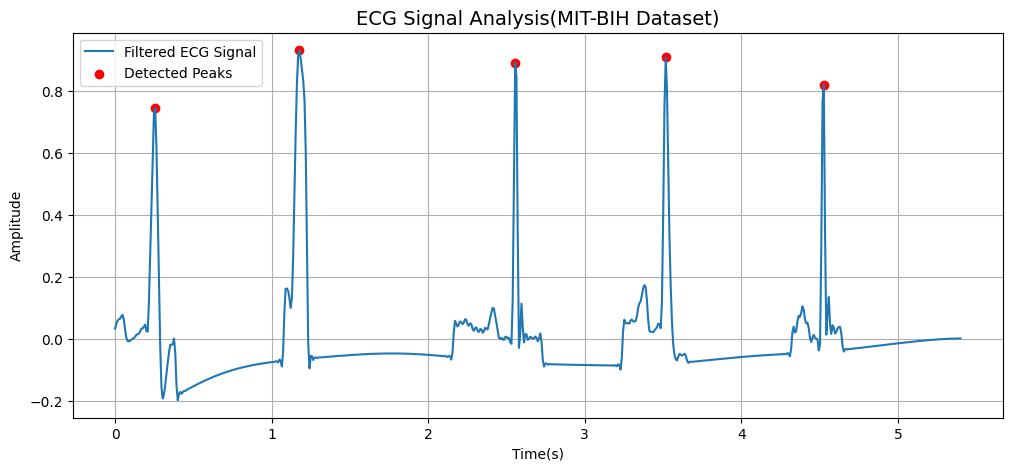

In [9]:
#Filter ECG signal
filtered = bandpass_filter(ecg, fs)

#Detect peaks
peaks = detect_peaks(filtered, fs)

#Estimate heart rate (beats per minute)
duration = len(ecg) / fs
heart_rate = (len(peaks) / duration) * 60

print(f"Estimated Heart Rate: {heart_rate:.2f} BPM")

#PLot ECG signal with detected peaks
plt.figure(figsize=(12,5))

plt.plot(t, filtered, label="Filtered ECG Signal", linewidth=1.5)
plt.scatter(t[peaks], filtered[peaks], color= "red" , label="Detected Peaks")

plt.xlabel("Time(s)")
plt.ylabel("Amplitude")
plt.title("ECG Signal Analysis(MIT-BIH Dataset)", fontsize=14)
plt.legend()
plt.grid()

plt.show()

### 5.Mathematical Formulation

This section outlines the mathematical principles used in ECG signal processing and heart rate eastimation.

---

#### Sampling and Time Axis

The time axis is constructed using the sampling frequency:

$$
t_n = \frac{n}{f_s}
$$

where:
- $t_n$ = time at sample $n$ (seconds, s)
- $n$ = sample index
- $f_s$ = sampling frequency (Hz)

---

#### Bandpass filtering

The ECG signal is filtered within the physiological frequency range:

$$
0.5 \leq f \leq 40 \, \text{Hz}
$$

This removes:
- Low-frequency drift (baseline wander)
- High-frequency noise

---

#### Peak Detection

Heartbeats correspond to peaks in the ECG signal:

$$
\text{Peaks} = \{t_i \mid x(t_i) > \text{threshold} \}
$$

with constraints:
- MInimum spacing: $\Delta t \approx 0.6 \, \text{s}$
- Amplitude threshold applied to reduce noise

---

#### Heart Rate Estimation

Heart rate is calculated as:

$$
HR = \frac{N_{\text{peaks}}}{T} \times 60
$$

where:
- $HR$ = heart rate (beats per minute, BPM)
- $N_{\text{peaks}}$ = number of detected peaks
- $T$ = total signal duration
  (seconds, s)

---

#### Signal Representation

The ECG signal is treated as a discrete time series:

$$
x(t_n)
$$

where amplitude is given in arbitrary units (anun) due to dataset normalisation.

---

### Summary

These formulations show how discrete signal processing techniques are applied to extract physiological information such as heart rate from ECG data.

  


## Results

The ECG signal shows a clear QRS complex, representing ventricular depolarisation.

Peak detection succesfully identifies heartbeats, allowing estimation of heart rate from real physiological data.